In [ ]:
# imports
import yfinance as yf
import pandas as pd
import numpy as np
import time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import altair as alt
from google.colab import files
pio.renderers.default = "colab"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok = True)

In [ ]:
# Asset Data
asset_info = pd.DataFrame([
    # Sectors
    {"Ticker": "SPY",  "Name": "SPDR S&P 500 ETF Trust", "Type": "Market", "Sector": "Market"},
    {"Ticker": "XLK",  "Name": "Technology Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Technology"},
    {"Ticker": "XLF",  "Name": "Financial Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Financials"},
    {"Ticker": "XLE",  "Name": "Energy Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Energy"},
    {"Ticker": "XLV",  "Name": "Health Care Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Health Care"},
    {"Ticker": "XLY",  "Name": "Consumer Discretionary Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Consumer Discretionary"},
    {"Ticker": "XLP",  "Name": "Consumer Staples Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Consumer Staples"},
    {"Ticker": "XLI",  "Name": "Industrial Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Industrials"},
    {"Ticker": "XLU",  "Name": "Utilities Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Utilities"},
    {"Ticker": "XLB",  "Name": "Materials Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Materials"},
    {"Ticker": "XLRE", "Name": "Real Estate Select Sector SPDR Fund", "Type": "Sector ETF", "Sector": "Real Estate"},
    # Stocks
    {"Ticker": "NVDA", "Name": "NVIDIA", "Type": "Stock", "Sector": "Technology"},
    {"Ticker": "AAPL", "Name": "Apple", "Type": "Stock", "Sector": "Technology"},
    {"Ticker": "MSFT", "Name": "Microsoft", "Type": "Stock", "Sector": "Technology"},
    {"Ticker": "AMD",  "Name": "AMD", "Type": "Stock", "Sector": "Technology"},
    {"Ticker": "META", "Name": "Meta", "Type": "Stock", "Sector": "Communication Services"},
    {"Ticker": "GOOG", "Name": "Alphabet", "Type": "Stock", "Sector": "Communication Services"},
    {"Ticker": "AMZN", "Name": "Amazon", "Type": "Stock", "Sector": "Consumer Discretionary"},
    {"Ticker": "TSLA", "Name": "Tesla", "Type": "Stock", "Sector": "Consumer Discretionary"},
    {"Ticker": "JPM",  "Name": "JPMorgan Chase", "Type": "Stock", "Sector": "Financials"},
    {"Ticker": "XOM",  "Name": "Exxon Mobil", "Type": "Stock", "Sector": "Energy"},
    {"Ticker": "LLY",  "Name": "Eli Lilly", "Type": "Stock", "Sector": "Health Care"}
])
tickers = asset_info["Ticker"].tolist()
sector_map = dict(zip(
    asset_info.loc[asset_info["Type"] == "Sector ETF", "Ticker"],
    asset_info.loc[asset_info["Type"] == "Sector ETF", "Sector"]
))

In [ ]:
START_DATE = "2022-01-01"
END_DATE = "2025-12-31"
all_data = {}
failed_tickers = []
for ticker in tickers:
    try:
        temp = yf.download(
            ticker,
            start = START_DATE,
            end = END_DATE,
            auto_adjust = False,
            progress = False,
            threads = False
        )
        if temp.empty:
            failed_tickers.append(ticker)
        else:
            if isinstance(temp.columns, pd.MultiIndex):
                temp.columns = temp.columns.droplevel(-1)
            all_data[ticker] = temp
        time.sleep(2)
    except Exception as e:
        print(f"Failed: {ticker} -> {e}")
        failed_tickers.append(ticker)
print("Downloaded:", list(all_data.keys()))
print("Failed:", failed_tickers)

Downloaded: ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'XLRE', 'NVDA', 'AAPL', 'MSFT', 'AMD', 'META', 'GOOG', 'AMZN', 'TSLA', 'JPM', 'XOM', 'LLY']
Failed: []


In [ ]:
frames = []
for ticker, temp in all_data.items():
    temp = temp.reset_index()
    temp["Ticker"] = ticker
    frames.append(temp)
prices_long = pd.concat(frames, ignore_index = True)
prices_long = prices_long.merge(asset_info, on = "Ticker", how = "left")
prices_long = prices_long.sort_values(["Ticker", "Date"]).reset_index(drop = True)
prices_long.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Name,Type,Sector
0,2022-01-03,178.103668,182.009995,182.880005,177.710007,177.830002,104487900,AAPL,Apple,Stock,Technology
1,2022-01-04,175.843262,179.699997,182.940002,179.119995,182.630005,99310400,AAPL,Apple,Stock,Technology
2,2022-01-05,171.165802,174.919998,180.169998,174.639999,179.610001,94537600,AAPL,Apple,Stock,Technology
3,2022-01-06,168.308502,172.000000,175.300003,171.639999,172.699997,96904000,AAPL,Apple,Stock,Technology
4,2022-01-07,168.474838,172.169998,174.139999,171.029999,172.889999,86709100,AAPL,Apple,Stock,Technology


In [ ]:
prices_long["Daily_Return"] = prices_long.groupby("Ticker")["Close"].pct_change()
prices_long["Log_Return"] = prices_long.groupby("Ticker")["Close"].transform(lambda x: np.log(x / x.shift(1)))
prices_long["Vol_7D"] = prices_long.groupby("Ticker")["Daily_Return"].transform(lambda x: x.rolling(7).std())
prices_long["Vol_30D"] = prices_long.groupby("Ticker")["Daily_Return"].transform(lambda x: x.rolling(30).std())
prices_long["MA_7"] = prices_long.groupby("Ticker")["Close"].transform(lambda x: x.rolling(7).mean())
prices_long["MA_30"] = prices_long.groupby("Ticker")["Close"].transform(lambda x: x.rolling(30).mean())
prices_long["Momentum_7D"] = prices_long.groupby("Ticker")["Close"].pct_change(7)
prices_long["Momentum_30D"] = prices_long.groupby("Ticker")["Close"].pct_change(30)
prices_long["Base100"] = prices_long.groupby("Ticker")["Close"].transform(
    lambda s: s / s.iloc[0] * 100 if len(s.dropna()) > 0 else s
)
spy_returns = prices_long.loc[prices_long["Ticker"] == "SPY", ["Date", "Daily_Return"]].rename(
    columns={"Daily_Return": "SPY_Return"}
)
prices_long = prices_long.merge(spy_returns, on = "Date", how = "left")
prices_long["Excess_Return"] = prices_long["Daily_Return"] - prices_long["SPY_Return"]
def rolling_beta(group, window = 30):
    cov = group["Daily_Return"].rolling(window).cov(group["SPY_Return"])
    var = group["SPY_Return"].rolling(window).var()
    return cov / var
prices_long["Rolling_Beta_30D"] = (
    prices_long.groupby("Ticker", group_keys = False)
    .apply(rolling_beta)
)
cleaned_data = prices_long.dropna(subset = [
    "Daily_Return", "Log_Return", "Vol_7D", "Vol_30D",
    "MA_7", "MA_30", "Momentum_7D", "Momentum_30D",
    "SPY_Return", "Excess_Return"
]).copy()
print("Raw rows:", prices_long.shape[0])
print("Cleaned rows:", cleaned_data.shape[0])
print("Columns:", cleaned_data.shape[1])
print(cleaned_data.columns.tolist())

Raw rows: 22044
Cleaned rows: 21384
Columns: 23
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Name', 'Type', 'Sector', 'Daily_Return', 'Log_Return', 'Vol_7D', 'Vol_30D', 'MA_7', 'MA_30', 'Momentum_7D', 'Momentum_30D', 'Base100', 'SPY_Return', 'Excess_Return', 'Rolling_Beta_30D']


/tmp/ipykernel_1196/3254506114.py:23: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
# Local Save
asset_info.to_csv(DATA_DIR / "asset_info.csv", index = False)
prices_long.to_csv(DATA_DIR / "prices_long_raw.csv", index = False)
cleaned_data.to_csv(DATA_DIR / "prices_long_cleaned.csv", index = False)

In [ ]:
monthly_frames = []
for ticker in prices_long["Ticker"].unique():
    temp = prices_long[prices_long["Ticker"] == ticker].copy()
    temp = temp.sort_values("Date")
    temp = temp.resample("ME", on="Date").last().reset_index()
    temp["Ticker"] = ticker
    monthly_frames.append(temp)
monthly_long = pd.concat(monthly_frames, ignore_index = True)
monthly_long = monthly_long.drop(columns = ["Name", "Type", "Sector"], errors = "ignore")
monthly_long = monthly_long.merge(
    asset_info[["Ticker", "Name", "Type", "Sector"]],
    on = "Ticker",
    how = "left"
)
monthly_long["Monthly_Return"] = monthly_long.groupby("Ticker")["Close"].pct_change()
monthly_long["Base100_Monthly"] = monthly_long.groupby("Ticker")["Close"].transform(
    lambda s: s / s.iloc[0] * 100 if len(s.dropna()) > 0 else s
)
monthly_long.to_csv(DATA_DIR / "monthly_prices_long.csv", index = False)
monthly_long.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Daily_Return,Log_Return,...,Momentum_30D,Base100,SPY_Return,Excess_Return,Rolling_Beta_30D,Name,Type,Sector,Monthly_Return,Base100_Monthly
0,2022-01-31,171.028809,174.779999,175.000000,169.509995,170.160004,115541600,AAPL,0.026126,0.025790,...,NaN,96.027693,0.018011,0.008115,NaN,Apple,Stock,Technology,NaN,100.000000
1,2022-02-28,161.782028,165.119995,165.419998,162.429993,163.059998,95056600,AAPL,0.001638,0.001636,...,-0.041059,90.720290,-0.002559,0.004196,1.216637,Apple,Stock,Technology,-0.055270,94.473050
2,2022-03-31,171.080170,174.610001,178.029999,174.399994,177.839996,103049300,AAPL,-0.017776,-0.017936,...,0.011939,95.934293,-0.015391,-0.002384,1.150676,Apple,Stock,Technology,0.057473,99.902736
3,2022-04-30,154.463013,157.649994,166.199997,157.250000,161.839996,131747600,AAPL,-0.036605,-0.037292,...,-0.018491,86.616119,-0.036956,0.000351,1.242988,Apple,Stock,Technology,-0.097131,90.199105
4,2022-05-31,146.045380,148.839996,150.660004,146.839996,149.070007,103718400,AAPL,-0.005346,-0.005361,...,-0.098322,81.775727,-0.005611,0.000265,1.347611,Apple,Stock,Technology,-0.055883,85.158483


In [ ]:
# User Selection
selected_assets = ["SPY", "XLK", "XLF", "NVDA", "AAPL"]
selected_sector = "Technology"
selected_stock = "NVDA"

# Visualization 1: S&P 500 vs Sectors


In [ ]:
line_data = monthly_long[monthly_long["Ticker"].isin(selected_assets)].copy()
fig_line = px.line(
    line_data,
    x = "Date",
    y = "Base100_Monthly",
    color = "Ticker",
    hover_data = ["Name", "Sector", "Type"],
    title = "Growth of Selected Assets (Base 100 Comparison)"
)
fig_line.update_layout(
    xaxis_title = "Date",
    yaxis_title = "Index (Base 100)"
)
fig_line.show()

This visualization compares how individual assets performed relative to the broader market, highlighting the outsized growth of NVDA compared to more stable assets like SPY


# Visualization 2: Heatmap for sectors

In [ ]:
sector_tickers = asset_info.loc[asset_info["Type"] == "Sector ETF", "Ticker"].tolist()
sector_monthly_long = monthly_long[monthly_long["Ticker"].isin(sector_tickers)][["Date", "Ticker", "Close"]].copy()
monthly_prices = sector_monthly_long.pivot(
    index = "Date",
    columns = "Ticker",
    values = "Close"
)
monthly_returns = monthly_prices.pct_change().dropna()
heatmap_df = monthly_returns.reset_index().melt(
    id_vars = "Date",
    var_name = "Ticker",
    value_name = "MonthlyReturn"
)
heatmap_df["Sector"] = heatmap_df["Ticker"].map(sector_map)
heatmap_chart = alt.Chart(heatmap_df).mark_rect().encode(
    x=alt.X("yearmonth(Date):T", title = "Month"),
    y=alt.Y("Sector:N", title = "Sector", sort = list(sector_map.values())),
    color = alt.Color(
        "MonthlyReturn:Q",
        title = "Monthly Return",
        scale = alt.Scale(scheme = "redyellowgreen")
    ),
    tooltip = [
        alt.Tooltip("Date:T", title = "Date"),
        alt.Tooltip("Ticker:N", title = "Ticker"),
        alt.Tooltip("Sector:N", title = "Sector"),
        alt.Tooltip("MonthlyReturn:Q", title = "Monthly Return", format = ".2%")
    ]
).properties(
    title = "Sector ETF Monthly Return Heatmap",
    width = 900,
    height = 350
)
heatmap_chart.display()
heatmap_chart.save("sector_heatmap_altair.html")

alt.Chart(...)

# Visualization 3: Bar Chart of Top Stocks in Chosen Sector

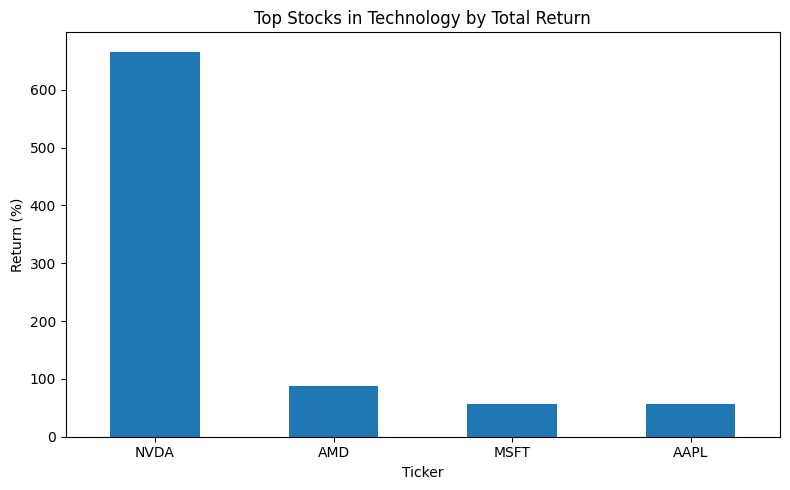

In [ ]:
sector_stocks = asset_info[
    (asset_info["Type"] == "Stock") & (asset_info["Sector"] == selected_sector)
]["Ticker"].tolist()
sector_stock_data = monthly_long[monthly_long["Ticker"].isin(sector_stocks)].copy()
sector_perf = (
    sector_stock_data.groupby("Ticker")["Base100_Monthly"]
    .last()
    .subtract(100)
    .sort_values(ascending=False)
)
plt.figure(figsize = (8, 5))
sector_perf.plot(kind = "bar")
plt.title(f"Top Stocks in {selected_sector} by Total Return")
plt.xlabel("Ticker")
plt.ylabel("Return (%)")
plt.xticks(rotation = 0)
plt.tight_layout()

#download data
plt.savefig("visual3.png", dpi=300, bbox_inches="tight")

plt.show()
sector_perf_df = sector_perf.reset_index()
sector_perf_df.columns = ["Ticker", "TotalReturn"]
sector_perf_df.to_csv(DATA_DIR / "top_sector_stocks.csv", index = False)

# Visualization 4: Candlestick of Stock's Daily Returns

In [ ]:
candle_data = prices_long[
    prices_long["Ticker"] == selected_stock
].dropna(subset = ["Open", "High", "Low", "Close"]).copy()
fig_candle = go.Figure(
    data=[
        go.Candlestick(
            x = candle_data["Date"],
            open = candle_data["Open"],
            high = candle_data["High"],
            low = candle_data["Low"],
            close = candle_data["Close"],
            name = selected_stock
        )
    ]
)
fig_candle.update_layout(
    title = f"{selected_stock} Candlestick Chart",
    xaxis_title = "Date",
    yaxis_title = "Price ($)",
    xaxis_rangeslider_visible = False,
    width = 950,
    height = 500
)
fig_candle.show()

# Visualization 5: Stock vs SPY

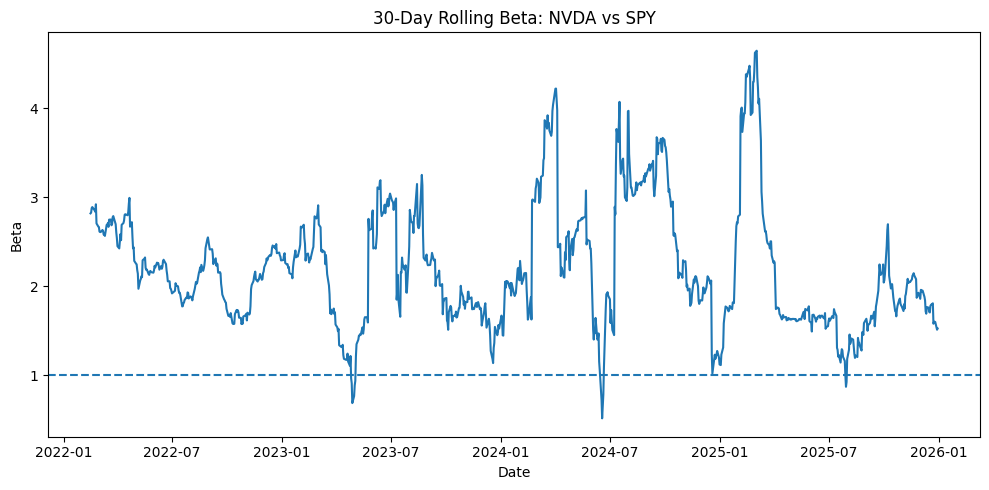

In [ ]:
beta_data = prices_long[prices_long["Ticker"] == selected_stock].copy()
plt.figure(figsize = (10, 5))
plt.plot(beta_data["Date"], beta_data["Rolling_Beta_30D"])
plt.axhline(1, linestyle = "--")
plt.title(f"30-Day Rolling Beta: {selected_stock} vs SPY")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.tight_layout()

#download data
plt.savefig("visual5.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
## Saving sector data
sector_etfs = ["XLK", "XLF", "XLE", "XLV", "XLY", "XLP", "XLI", "XLU", "XLB", "XLRE"]

d3_data = monthly_long[
    monthly_long["Ticker"].isin(sector_etfs)
][["Date", "Ticker", "Sector", "Base100_Monthly"]].copy()

d3_data.to_csv("data/monthly_prices_long.csv", index=False)

# Download data
files.download("data/monthly_prices_long.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# save Plotly charts
fig_line.write_html("visual1.html")
fig_candle.write_html("visual4.html")

# save Altair chart
heatmap_chart.save("visual2.html")